In [2]:
"""
define our unit systems
want:

characteristic mass scale = 1e10 Msun = 1e10 * 2e33 g = 2e43 g
characteristic velocity scale = 100 km/s = 1e7 cm/s
characteristic length scale = 1 kpc = 3.086e21 cm

"""

'\ndefine our unit systems\nwant:\n\ncharacteristic mass scale = 1e10 Msun = 1e10 * 2e33 g = 2e43 g\ncharacteristic velocity scale = 100 km/s = 1e7 cm/s\ncharacteristic length scale = 1 kpc = 3.086e21 cm\n\n'

In [3]:
Msun = 2e33  # grams
kms  = 1e5   # cm/s
kb   = 1.38e-16 # erg / K = g * (cm/s)^2 / K
mp   = 1.6e-24 # grams
mu   = 0.6 # appropriate for an ionized plasma
yr   = 3.154e7
Myr  = 1e6 * yr
Gyr  = 1e9 * yr
kpc =  3.086e21 # cm
K   = 1 # K

# gravitational constant in (kpc, km/s, Msun) units
G_kpc_kms2_Msun = 4.30091e-6   # kpc (km/s)^2 / Msun

# conversion: (km/s)/Mpc → 1/Gyr
H_unit_conv = 0.0010227

code_mass      = 1e10 * Msun # code mass of 1 corresponds to 1e10 Msun = 2e43 grams
code_velocity  = 1e2 * kms  # code velocity of 1 corresponds to 100 km/s = 1e7 cm/s
code_length    = kpc # code length of 1 corresponds to 1 kpc = 3.086e21 cm

code_time        = code_length / code_velocity
code_temperature = (mu * mp / kb) * code_velocity**2

print("code_time = ", code_time/Gyr, " Gyr")
print("code_temperature = ", code_temperature, " K")

code_time =  0.009784400760938491  Gyr
code_temperature =  695652.1739130436  K


In [4]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

from astropy.cosmology import Planck15 as cosmo
from astropy.cosmology import z_at_value
from astropy import units as u

f_B = 0.16
# A_cool = 0.1         # Mdot_in ∝ A_cool * M_CGM^2 * T_CGM^{-2/3}

# t_dep0 is the normalization of the depletion time
# t_dep_exp is the exponent for the dependence on ISM mass
# t_dep0    = 1.0
# t_dep_exp = 0.0      # -1, -0.5, 0, 0.5, 1, which is beta

# eta_M0 is the normalization of the mass loading factor
# eta_M_exp is the exponent for the dependence on ISM mass
# eta_M0    = 1.0
# eta_M_exp = 0.0      # -1, 0, 1

# eta_E0 is the normalization of the energy loading factor
# eta_E_exp is the exponent for the dependence on ISM mass
# eta_E0    = 0.3
# eta_E_exp = 0.0      # -1, 0, 1

# igm_accretion_heating_coefficient = 0.5   # α
# cooling_coefficient               = 0.5   # c

# Convention:
# All mass flow rates are in units of code_mass / code_time

def build_z_of_t_interpolator(tmin_gyr=0.5, tmax_gyr=13.7, n=5000):
    
    z_grid = np.linspace(0.0, 12.0, n)
    t_grid = cosmo.age(z_grid).to_value(u.Gyr)

    order = np.argsort(t_grid)
    t_sorted = t_grid[order]
    z_sorted = z_grid[order]

    def z_of_t(t_gyr):
        t = np.asarray(t_gyr)
        t_clipped = np.clip(t, t_sorted[0], t_sorted[-1])
        return np.interp(t_clipped, t_sorted, z_sorted)

    return z_of_t

z_of_t = build_z_of_t_interpolator()

def Mhalo_of_z(z, M0=1e12, alpha=1.6, beta=-1.2):
    return M0 * (1.0 + z)**alpha * np.exp(beta * z)

def dMdz(z, M0=1e12, alpha=1.6, beta=-1.2):
    M = Mhalo_of_z(z, M0=M0, alpha=alpha, beta=beta)
    return M * (alpha / (1.0 + z) + beta)

def H_per_Gyr(z):
    return cosmo.H(z).to_value(u.km/u.s/u.Mpc) * H_unit_conv

def Mdot_halo_Msun_per_Gyr(z, M0=1e12, alpha=1.6, beta=-1.2):
    dzdt = -H_per_Gyr(z) * (1.0 + z)
    return dMdz(z, M0=M0, alpha=alpha, beta=beta) * dzdt

def mdot_halo(t_code, M0=1e12, alpha=1.6, beta=-1.2):

    t_gyr = t_code * (code_time / Gyr)

    z = z_of_t(t_gyr)

    mdot_phys = Mdot_halo_Msun_per_Gyr(z, M0=M0, alpha=alpha, beta=beta)

    mdot_unit = (code_mass / Msun) / (code_time / Gyr)
    return mdot_phys / mdot_unit

def rho_crit_Msun_kpc3(z):
    # critical density in Msun/kpc^3
    return cosmo.critical_density(z).to_value(u.Msun / u.kpc**3)

def virial_quantities(z, M0=1e12, alpha=1.6, beta=-1.2, Delta=200.0):

    M = Mhalo_of_z(z, M0=M0, alpha=alpha, beta=beta)      # Msun
    rho_c = rho_crit_Msun_kpc3(z)                         # Msun/kpc^3

    Rvir = (3.0 * M / (4.0 * np.pi * Delta * rho_c))**(1.0/3.0)   # kpc
    Vvir = np.sqrt(G_kpc_kms2_Msun * M / Rvir)                    # km/s

    V_cms = Vvir * 1e5                                            # cm/s
    Tvir = (mu * mp / (2.0 * kb)) * V_cms**2                      # K

    return M, Rvir, Vvir, Tvir


def mdot_in_function(A_cool, M_CGM, T_CGM):
    return A_cool * M_CGM**2 * T_CGM**(-2.0/3.0)

M_ISM0_physical = 1e10*Msun
M_ISM0 = M_ISM0_physical / code_mass

T_CGM0_physical = 1e6*K
T_CGM0 = T_CGM0_physical / code_temperature

M_CGM0  = 1.0
M_star0 = 0.0


M_ISM_ref = M_ISM0
M_CGM_ref = M_CGM0
T_CGM_ref = T_CGM0
M_star_ref = M_ISM_ref


def galaxy_cgm_evolution(t, z,
                         A_cool,
                         t_dep0, t_dep_exp,
                         eta_M0, eta_M_exp,
                         eta_E0, eta_E_exp,
                         igm_accretion_heating_coefficient = 0.5,
                         cooling_coefficient = 0.5):
    M_ISM, T_CGM, M_CGM, M_star = z

    M_ISM_safe = max(M_ISM, 1e-12)
    T_CGM_safe = max(T_CGM, 1e-6)

    mdot_IGM  = f_B * mdot_halo(t)
    mdot_in   = mdot_in_function(A_cool, M_CGM, T_CGM)

    t_dep     = t_dep0 * (M_ISM_safe / M_ISM_ref)**t_dep_exp
    mdot_star = M_ISM_safe / t_dep

    eta_M     = eta_M0 * (M_ISM_safe / M_ISM_ref)**eta_M_exp
    mdot_wind = eta_M * mdot_star

    eta_E     = eta_E0 * (M_ISM_safe / M_ISM_ref)**eta_E_exp

    dM_cgm_dt = mdot_IGM - mdot_in + mdot_wind
    dM_ism_dt = mdot_in - mdot_wind - mdot_star
    dT_cgm_dt = (igm_accretion_heating_coefficient * mdot_IGM
                 + eta_E * mdot_wind
                 - cooling_coefficient * mdot_in)
    dM_star_dt = mdot_star

    return [dM_ism_dt, dT_cgm_dt, dM_cgm_dt, dM_star_dt]

def galaxy_cgm_evolution_terms(t, z,
                        A_cool,
                        t_dep0, t_dep_exp,
                        eta_M0, eta_M_exp,
                        eta_E0, eta_E_exp,
                        igm_accretion_heating_coefficient = 0.5,
                        cooling_coefficient = 0.5):
    M_ISM, T_CGM, M_CGM, M_star = z

    M_ISM_safe = max(M_ISM, 1e-12)
    T_CGM_safe = max(T_CGM, 1e-6)

    mdot_IGM  = f_B * mdot_halo(t)
    mdot_in   = mdot_in_function(A_cool, M_CGM, T_CGM)

    t_dep     = t_dep0 * (M_ISM_safe / M_ISM_ref)**t_dep_exp
    mdot_star = M_ISM_safe / t_dep

    eta_M     = eta_M0 * (M_ISM_safe / M_ISM_ref)**eta_M_exp
    mdot_wind = eta_M * mdot_star

    eta_E     = eta_E0 * (M_ISM_safe / M_ISM_ref)**eta_E_exp

    dM_cgm_dt = mdot_IGM - mdot_in + mdot_wind
    dM_ism_dt = mdot_in - mdot_wind - mdot_star
    dT_cgm_dt = (igm_accretion_heating_coefficient * mdot_IGM
                 + eta_E * mdot_wind
                 - cooling_coefficient * mdot_in)
    dM_star_dt = mdot_star

    derivatives = {}
    # ISM: total, +inflow, -wind, -SFR
    derivatives['dM_ism_dt'] = np.array([
        dM_ism_dt,
        mdot_in,
        -mdot_wind,
        -mdot_star])

    # CGM: total, +IGM, -inflow, +wind
    derivatives['dM_cgm_dt'] = np.array([
        dM_cgm_dt,
        mdot_IGM,
        -mdot_in,
        mdot_wind])

    # T_CGM: total, IGM heating, wind heating, -cooling
    derivatives['dT_cgm_dt'] = np.array([
        dT_cgm_dt,
        igm_accretion_heating_coefficient * mdot_IGM,
        eta_E * mdot_wind,
        -cooling_coefficient * mdot_in])

    # M_star: total, SFR
    derivatives['dM_star_dt'] = np.array([
        dM_star_dt,
        mdot_star])

    return derivatives

def stop_floor_event(t, z,
                     A_cool,
                     t_dep0, t_dep_exp,
                     eta_M0, eta_M_exp,
                     eta_E0, eta_E_exp,
                     igm_accretion_heating_coefficient,
                     cooling_coefficient,
                     eps=1e-12):

    M_ISM, T_CGM, M_CGM, M_star = z

    m_ism_margin = (M_ISM / M_ISM_ref) - eps
    m_cgm_margin = (M_CGM / M_CGM_ref) - eps
    t_cgm_margin = (T_CGM / T_CGM_ref) - eps

    return min(m_ism_margin, m_cgm_margin, t_cgm_margin)

stop_floor_event.terminal = True
stop_floor_event.direction = -1


def run_model(A_cool,
              t_dep0, t_dep_exp,
              eta_M0, eta_M_exp,
              eta_E0, eta_E_exp,
              igm_accretion_heating_coefficient = 0.5,
              cooling_coefficient = 0.5,
              t_end=20.0,
              n_steps=2000):

    z0 = [M_ISM0, T_CGM0, M_CGM0, M_star0]

    t_span = (0.0, t_end)
    t_eval = np.linspace(*t_span, n_steps)

    sol = solve_ivp(
        galaxy_cgm_evolution,
        t_span,
        z0,
        t_eval=t_eval,
        method="LSODA",
        rtol=1e-6,
        atol=1e-9,
        events=[stop_floor_event],
        args=(A_cool,
              t_dep0, t_dep_exp,
              eta_M0, eta_M_exp,
              eta_E0, eta_E_exp,
              igm_accretion_heating_coefficient,
              cooling_coefficient))

    t = sol.t
    M_ism_sol  = sol.y[0]
    T_cgm_sol  = sol.y[1]
    M_cgm_sol  = sol.y[2]
    M_star_sol = sol.y[3]

    n = len(t)
    dM_ism_terms  = np.zeros((4, n))
    dT_cgm_terms  = np.zeros((4, n))
    dM_cgm_terms  = np.zeros((4, n))
    dM_star_terms = np.zeros((2, n))

    for i, (ti, zi) in enumerate(zip(t, sol.y.T)):
        derivs = galaxy_cgm_evolution_terms(ti, zi,
                        A_cool,
                        t_dep0, t_dep_exp,
                        eta_M0, eta_M_exp,
                        eta_E0, eta_E_exp,
                        igm_accretion_heating_coefficient,
                        cooling_coefficient)
        dM_ism_terms[:, i]  = derivs['dM_ism_dt']
        dT_cgm_terms[:, i]  = derivs['dT_cgm_dt']
        dM_cgm_terms[:, i]  = derivs['dM_cgm_dt']
        dM_star_terms[:, i] = derivs['dM_star_dt']

    return (t,
            M_ism_sol, T_cgm_sol, M_cgm_sol, M_star_sol,
            dM_ism_terms, dT_cgm_terms, dM_cgm_terms, dM_star_terms)

def make_filename(prefix, A, beta, eta_M, eta_E, ext="png"):
    return f"{prefix}_A{A}_beta{beta}_etaM{eta_M}_etaE{eta_E}.{ext}"

In [5]:
t_gyr = 13.7
z = z_of_t(t_gyr)

M, Rvir, Vvir, Tvir = virial_quantities(z)

print("z =", z)
print("M =", M, "Msun")
print("Rvir =", Rvir, "kpc")
print("Vvir =", Vvir, "km/s")
print("Tvir =", Tvir, "K")

z = 0.006796937639702654
M = 1002685582722.1593 Msun
Rvir = 210.58608303448923 kpc
Vvir = 143.10266747935793 km/s
Tvir = 712291.2500767891 K


In [6]:
def plot_derivs(A_cool,
              t_dep0, t_dep_exp,
              eta_M0, eta_M_exp,
              eta_E0, eta_E_exp,
              igm_accretion_heating_coefficient = 0.5,
              cooling_coefficient = 0.5,
              t_end=20.0,
              n_steps=2000):

    (t,
     M_ism_sol, T_cgm_sol, M_cgm_sol, M_star_sol,
     dM_ism_terms, dT_cgm_terms, dM_cgm_terms, dM_star_terms) = run_model(A_cool,
              t_dep0, t_dep_exp,
              eta_M0, eta_M_exp,
              eta_E0, eta_E_exp,
              igm_accretion_heating_coefficient,
              cooling_coefficient,
              t_end,
              n_steps)


    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
    ax_mass, ax_T = axes[0]
    ax_ISM, ax_CGM = axes[1]

    ax_mass.plot(t, dM_ism_terms[0], label="M_ISM")
    ax_mass.plot(t, dM_cgm_terms[0], label="M_CGM")
    ax_mass.plot(t, dM_star_terms[0], label="M_star")
    ax_mass.set_yscale("log")
    ax_mass.axhline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax_mass.set_ylabel("d Mass/dt (arb. units)")
    ax_mass.legend()
    ax_mass.grid(True)

        #     dT_cgm_dt,
        # igm_accretion_heating_coefficient * mdot_IGM,
        # eta_E * mdot_wind,
        # -cooling_coefficient * mdot_in])

    dT_CGM_total = dT_cgm_terms[0]
    igm_heating   = dT_cgm_terms[1]
    wind_heating  = dT_cgm_terms[2]
    cooling       = dT_cgm_terms[3]

    ax_T.plot(t, dT_CGM_total,   color="k", label="dT_CGM_dt")
    ax_T.plot(t, igm_heating,    color="C0", label="IGM heating")
    ax_T.plot(t, wind_heating,   color="C1", label="wind heating")
    ax_T.plot(t, cooling,        color="C2", label="cooling")
    ax_T.set_ylabel("d T_CGM/dt (arb. units)")
    ax_T.legend()
    ax_T.grid(True)

    dM_ism_total = dM_ism_terms[0]
    mdot_in      = dM_ism_terms[1]
    mdot_wind    = -dM_ism_terms[2]
    mdot_star    = -dM_ism_terms[3]

    ax_ISM.plot(t, dM_ism_total, color="k", label="dM_ism_dt")
    ax_ISM.plot(t, -mdot_in,      color="C0", label="-mdot_in")
    ax_ISM.plot(t, mdot_in,       "C0--",     label="mdot_in")
    ax_ISM.plot(t, mdot_wind,     color="C1", label="mdot_wind")
    ax_ISM.plot(t, mdot_star,     color="C2", label="mdot_star")

    ax_ISM.set_yscale("log")
    ax_ISM.set_ylabel("Mass rate (arb. units)")
    ax_ISM.set_xlabel("time")
    ax_ISM.legend(fontsize=8)
    ax_ISM.grid(True)

    dM_cgm_total = dM_cgm_terms[0]
    mdot_IGM     = dM_cgm_terms[1]
    minus_mdot_in= dM_cgm_terms[2]
    mdot_in_CGM  = -minus_mdot_in
    mdot_wind_CGM= dM_cgm_terms[3]

    ax_CGM.plot(t, dM_cgm_total,   color="k",  label="dM_cgm_dt")
    ax_CGM.plot(t, mdot_IGM,       color="C0", label="mdot_IGM")
    ax_CGM.plot(t, minus_mdot_in,  color="C1", label="-mdot_in")
    ax_CGM.plot(t, mdot_in_CGM,    "C1--",     label="mdot_in")
    ax_CGM.plot(t, mdot_wind_CGM,  color="C2", label="mdot_wind")

    ax_CGM.set_yscale("log")
    ax_CGM.set_ylabel("Mass rate (arb. units)")
    ax_CGM.set_xlabel("time")
    ax_CGM.legend(fontsize=8)
    ax_CGM.grid(True)

    plt.tight_layout()

    filename = make_filename("derivs", A_cool, t_dep_exp, eta_M0, eta_E0)
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

In [7]:
def plot_state(A_cool,
              t_dep0, t_dep_exp,
              eta_M0, eta_M_exp,
              eta_E0, eta_E_exp,
              igm_accretion_heating_coefficient = 0.5,
              cooling_coefficient = 0.5,
              t_end=20.0,
              n_steps=2000):
    (t,
     M_ISM_sol,
     T_CGM_sol,
     M_CGM_sol,
     M_star_sol,
     dM_ism_terms,
     dT_cgm_terms,
     dM_cgm_terms,
     dM_star_terms) = run_model(A_cool,
              t_dep0, t_dep_exp,
              eta_M0, eta_M_exp,
              eta_E0, eta_E_exp,
              igm_accretion_heating_coefficient,
              cooling_coefficient,
              t_end,
              n_steps)

    fig, axes = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

    ax_mass, ax_T = axes

    ax_mass.plot(t, M_ISM_sol, label="M_ISM")
    ax_mass.plot(t, M_CGM_sol, label="M_CGM")
    ax_mass.plot(t, M_star_sol, label="M_star")
    ax_mass.set_ylabel("Mass(code units)")
    ax_mass.legend()
    ax_mass.grid(True)

    ax_T.plot(t, T_CGM_sol, label="T_CGM")
    ax_T.set_xlabel("t")
    ax_T.set_ylabel("T_CGM(code units)")
    ax_T.legend()
    ax_T.grid(True)

    for ax in axes:
        ax.set_yscale("log")

    plt.tight_layout()
    plt.show()

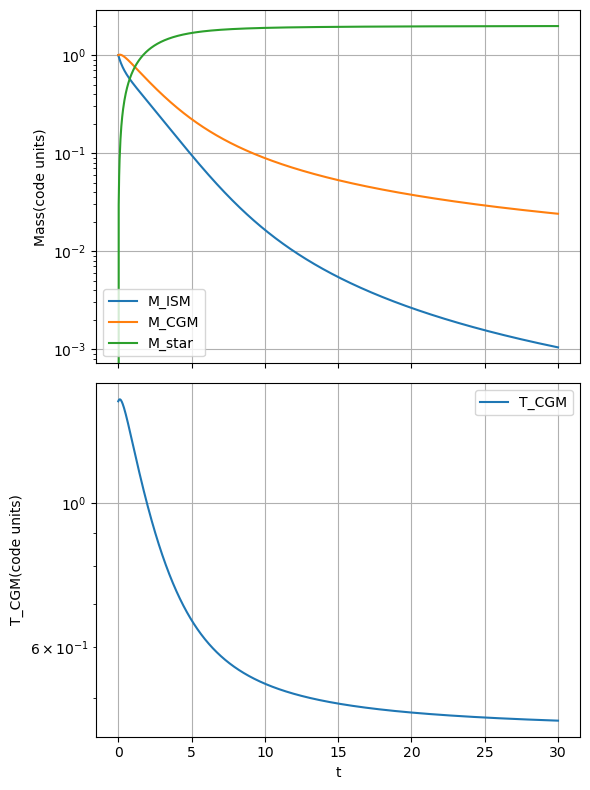

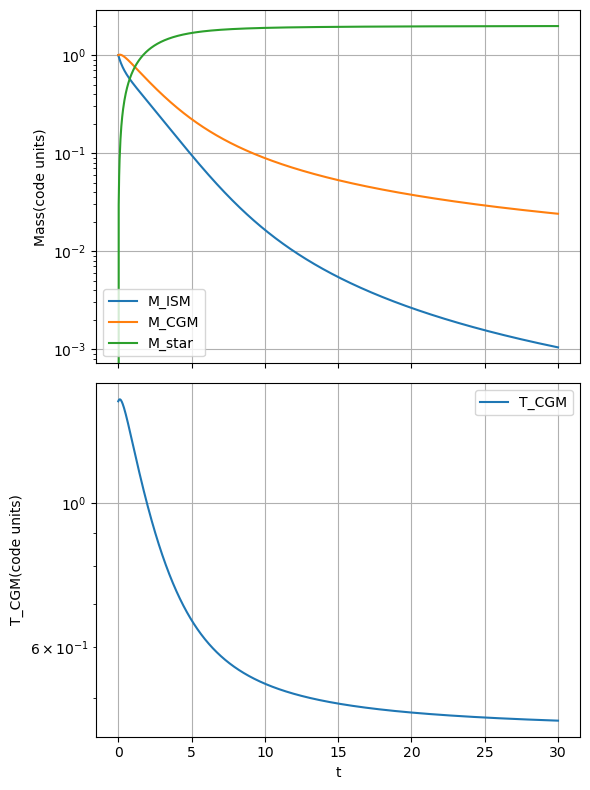

In [34]:
A_cool                            = 1.0

t_dep0                            = 1.0
t_dep_exp                         = 0.0

eta_M0                            = 1.0
eta_M_exp                         = 1.0

eta_E0                            = 1.0
eta_E_exp                         = 0.0

igm_accretion_heating_coefficient = 1.0
cooling_coefficient               = 1.0

t_end                             = 30.
n_steps                           = 1000

plot_state(A_cool,t_dep0, t_dep_exp, eta_M0, eta_M_exp, eta_E0, eta_E_exp, igm_accretion_heating_coefficient, cooling_coefficient, t_end, n_steps)
# plot_derivs(A_cool,t_dep0, t_dep_exp, eta_M0, eta_M_exp, eta_E0, eta_E_exp, igm_accretion_heating_coefficient, cooling_coefficient, t_end, n_steps)


plot_state(A_cool,t_dep0, t_dep_exp, eta_M0, eta_M_exp, eta_E0, eta_E_exp, igm_accretion_heating_coefficient, cooling_coefficient, t_end, n_steps)
# plot_derivs(A_cool,t_dep0, t_dep_exp, eta_M0, eta_M_exp, eta_E0, eta_E_exp, igm_accretion_heating_coefficient, cooling_coefficient, t_end, n_steps)
